# Perparing Data for Model Construction
## Explore the dataset
The dataset is collected in 2018. It has ultrasound images among women in ages of 25 to 75. The images are categorized into malignant (cancerous), benign(non cancerous) and normal. The dataset contains 780 images with an average image size of 500 * 500 pixels. 

#### Reference
Al-Dhabyani W, Gomaa M, Khaled H, Fahmy A. Dataset of breast ultrasound images. Data in Brief. 2020 Feb;28:104863. DOI: 10.1016/j.dib.2019.104863.

## Import the required packages

In [18]:
import os, glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [19]:
# modules from PyTorch
from sklearn.model_selection import train_test_split, StratifiedKFold

In [20]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
print('Using device: '+device_name)
device = torch.device(device_name)

Using device: mps


## Load images and functions to explore

The dataset already contained mask files, which shows the location, shape and size of the tumor. If no mask image is available, I can use either one of the the following annotation tools to create mask image files: 

* Label Studio (open-source; exports masks/COCO/YOLO polygons)
* CVAT (open-source; very good for polygons and DICOM)
* LabelMe (simple polygon tool; exports JSON you can rasterize)
* Roboflow Annotate (browser-based; easy for small projects)

In [21]:
ROOT = Path("../data/Dataset_BUSI_with_GT")
CLASSES = ["malignant", "benign", "normal"]  # folder names

In [22]:
def list_images(root=ROOT, classes=CLASSES):
    """Return list of (img_path, class_name). Skips mask files."""
    items = []
    for cname in classes:
        for p in (root / cname).glob("*.png"):
            if "_mask" in p.stem:  # skip mask files
                continue
            items.append((str(p), cname))
    return items

In [23]:
def load_image_rgb(path: str) -> np.ndarray:
    """Load an image with OpenCV and convert it to RGB for plotting."""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    # OpenCV uses BGR order; convert so Matplotlib shows correct colors.
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [24]:
def merge_masks_for_image(img_path):
    """
    BUSI masks follow '<name>_mask.png'. If multiple exist, merge them.
    If none exist (e.g., 'normal'), return a zero mask matching the image size.
    """
    root, ext = os.path.splitext(img_path)
    mask_paths = glob.glob(f"{root}_mask*.png")

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    h, w = img.shape[:2]

    if not mask_paths:
        return np.zeros((h, w), dtype=np.uint8)  # no lesion

    merged = np.zeros((h, w), dtype=np.uint8)
    for mp in mask_paths:
        m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        merged = np.maximum(merged, (m > 0).astype(np.uint8))  # binary OR
    return merged

In [25]:
items = list_images()
# Encode labels (malignant=2, benign=1, normal=0) — order matches CLASSES
label_map = {c:i for i,c in enumerate(CLASSES)}
labels = np.array([label_map[c] for _, c in items], dtype=np.int64)

## Split images into training and Testing

As we only have 780 images, I decided to use cross-validation method. That way, I can preserve the whole training dataset and also test the model on some unseen images (validation).  

In [26]:
train_idx, test_idx = train_test_split(
    np.arange(len(items)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [27]:
train_items = [items[i] for i in train_idx]
test_items  = [items[i] for i in test_idx]
train_labels = labels[train_idx]
test_labels  = labels[test_idx]

print(f"Total: {len(items)} | Train: {len(train_items)} | Test: {len(test_items)}")

Total: 780 | Train: 624 | Test: 156


In [28]:
# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

folds = []
for fold_id, (tr, va) in enumerate(skf.split(train_items, train_labels), 1):
    folds.append((tr, va))
    print(f"Fold {fold_id}: train {len(tr)} | val {len(va)}")

Fold 1: train 499 | val 125
Fold 2: train 499 | val 125
Fold 3: train 499 | val 125
Fold 4: train 499 | val 125
Fold 5: train 500 | val 124


## Example image overlayed with mask

Before plotting any examples, I define a few helper functions that load ultrasound images, merge all available mask files, and optionally visualize masks as overlays. Each helper is documented so you can see why it's needed.


In [40]:
def load_image_pil(path: str, mode: str = "RGB"):
    """Return the image at *path* converted to the Pillow *mode* you request."""
    # Centralized loader so every consumer benefits from consistent conversion.
    return Image.open(path).convert(mode)

After standardizing image loading via PIL, the next helper fuses any `_mask*.png` files associated with an ultrasound image into a single binary array that we can reuse downstream.


In [41]:
def merge_masks_pil(img_path: str) -> np.ndarray:
    """Combine every *_mask*.png for the image into a single binary mask."""
    root, _ = os.path.splitext(img_path)
    mask_paths = glob.glob(f"{root}_mask*.png")

    img = load_image_pil(img_path, mode="RGB")
    width, height = img.size

    if not mask_paths:
        return np.zeros((height, width), dtype=np.uint8)

    merged = None
    for mask_path in mask_paths:
        mask = load_image_pil(mask_path, mode="L")
        if mask.size != (width, height):
            # Align masks to the base image to ensure pixel-wise operations line up.
            mask = mask.resize((width, height), Image.NEAREST)
        mask_arr = (np.array(mask) > 0).astype(np.uint8)
        merged = mask_arr if merged is None else np.maximum(merged, mask_arr)

    return merged


To double-check the masks visually, I overlay them in red on top of the RGB image. That makes it easy to spot alignment issues before training.


In [42]:
def overlay_mask(img, mask, alpha: float = 0.35):
    """Blend a binary mask on top of an RGB image for quick visualization."""
    img_arr = np.array(img, copy=True).astype(float)
    highlight = np.array([255, 0, 0], dtype=float)  # bright red overlay
    img_arr[mask == 1] = alpha * highlight + (1 - alpha) * img_arr[mask == 1]
    return img_arr.astype(np.uint8)



The following cell runs those helpers on a representative malignant scan so you can see the raw image, mask, and overlay side-by-side.


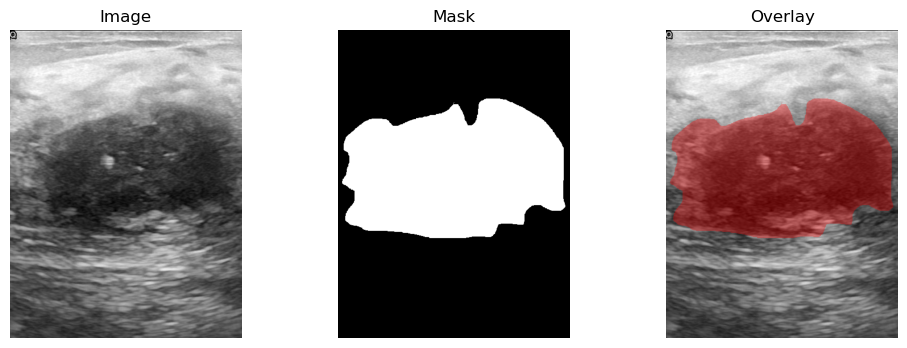

In [32]:
# Visual sanity check for merged masks.
img_path = "../data/Dataset_BUSI_with_GT/malignant/malignant (1).png"
img = load_image_pil(img_path)
mask = merge_masks_pil(img_path)
overlay = overlay_mask(img, mask)

plt.figure(figsize=(12, 4))
plt.subplot(1,3,1); plt.imshow(img); plt.axis('off'); plt.title("Image")
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.axis('off'); plt.title("Mask")
plt.subplot(1,3,3); plt.imshow(overlay); plt.axis('off'); plt.title("Overlay")
plt.show()

In [43]:
# Save file paths and labels to CSVs
pd.DataFrame({
    "path": [p for p, _ in train_items],
    "label": [c for _, c in train_items]
}).to_csv("../data/train_split.csv", index=False)

pd.DataFrame({
    "path": [p for p, _ in test_items],
    "label": [c for _, c in test_items]
}).to_csv("../data/test_split.csv", index=False)

print("Saved train_split.csv and test_split.csv to ../data/")


Saved train_split.csv and test_split.csv to ../data/


## Mask-aware dataset pipeline for modeling

These steps used to live in the modeling notebook; relocating them keeps all masking and preprocessing logic in one place. The code below defines the PyTorch dataset and helper routines that prepare dataloaders for training, validation, and testing.


**Resolution anchor.** I start by pinning a single spatial size that every transform and dataset references, which keeps augmentations and mask resizing in sync with the CNN input.


In [44]:
DEFAULT_IMAGE_SIZE: tuple[int, int] = (224, 224)  # standard resolution for the CNN

**Augmentation presets.** With the resolution locked in, I generate two torchvision pipelines: one deterministic transform for validation/test and another with flips, rotations, and small translations for training.


In [45]:
def get_default_transforms(image_size: tuple[int, int] = DEFAULT_IMAGE_SIZE):
    """Return both the evaluation transform and the augmentation-heavy train transform."""
    base_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),  # center pixel range around 0
    ])

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    return base_transform, train_transform

**Custom dataset.** The `BUSIDataset` class handles grayscale conversion, optional mask concatenation, and augmentation logic, so every downstream loader stays lean.


In [46]:
class BUSIDataset(Dataset):
    """PyTorch dataset that optionally appends lesion masks as an extra channel."""

    def __init__(
        self,
        csv_file,
        label_map,
        transform=None,
        use_masks: bool = True,
        is_training: bool = False,
        image_size: tuple[int, int] = DEFAULT_IMAGE_SIZE,
    ):
        self.df = pd.read_csv(csv_file)
        self.label_map = label_map
        self.transform = transform
        self.use_masks = use_masks
        self.is_training = is_training
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def _joint_augmentations(self, img_gray, mask_pil):
        """Apply geometric transforms that must affect the image and mask identically."""
        if np.random.random() < 0.5:
            img_gray = img_gray.transpose(Image.FLIP_LEFT_RIGHT)
            mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)

        angle = np.random.uniform(-15, 15)
        img_gray = img_gray.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
        mask_pil = mask_pil.rotate(angle, resample=Image.NEAREST, fillcolor=0)

        translate_x = np.random.uniform(-0.15, 0.15) * img_gray.size[0]
        translate_y = np.random.uniform(-0.15, 0.15) * img_gray.size[1]
        img_gray = img_gray.transform(
            img_gray.size,
            Image.AFFINE,
            (1, 0, translate_x, 0, 1, translate_y),
            fillcolor=0,
        )
        mask_pil = mask_pil.transform(
            mask_pil.size,
            Image.AFFINE,
            (1, 0, translate_x, 0, 1, translate_y),
            fillcolor=0,
        )

        scale = np.random.uniform(0.9, 1.1)
        orig_w, orig_h = img_gray.size
        new_size = (int(orig_w * scale), int(orig_h * scale))
        img_gray = img_gray.resize(new_size, Image.LANCZOS)
        mask_pil = mask_pil.resize(new_size, Image.NEAREST)

        if scale > 1.0:
            left = (new_size[0] - orig_w) // 2
            top = (new_size[1] - orig_h) // 2
            img_gray = img_gray.crop((left, top, left + orig_w, top + orig_h))
            mask_pil = mask_pil.crop((left, top, left + orig_w, top + orig_h))
        else:
            new_img = Image.new('L', (orig_w, orig_h), 0)
            new_mask = Image.new('L', (orig_w, orig_h), 0)
            paste_x = (orig_w - new_size[0]) // 2
            paste_y = (orig_h - new_size[1]) // 2
            new_img.paste(img_gray, (paste_x, paste_y))
            new_mask.paste(mask_pil, (paste_x, paste_y))
            img_gray = new_img
            mask_pil = new_mask

        return img_gray, mask_pil

    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        img_path = sample['path']
        label_str = sample['label']

        img_rgb = Image.open(img_path).convert('RGB')

        if self.use_masks:
            mask = merge_masks_pil(img_path)
            mask_pil = Image.fromarray(mask)
            img_gray = img_rgb.convert('L')

            if self.is_training:
                img_gray, mask_pil = self._joint_augmentations(img_gray, mask_pil)

            img_gray = img_gray.resize(self.image_size, Image.LANCZOS)
            mask_pil = mask_pil.resize(self.image_size, Image.NEAREST)

            img_gray_t = transforms.ToTensor()(img_gray)
            mask_t = transforms.ToTensor()(mask_pil)

            img_gray_t = transforms.Normalize(mean=[0.5], std=[0.5])(img_gray_t)
            mask_t = transforms.Normalize(mean=[0.5], std=[0.5])(mask_t)

            img_tensor = torch.cat([img_gray_t, mask_t], dim=0)
        else:
            img_gray = img_rgb.convert('L')
            img_tensor = self.transform(img_gray) if self.transform else transforms.ToTensor()(img_gray)

        label = self.label_map[label_str]
        return img_tensor, label


**Split helpers.** Given CSV paths and the label map, this next helper instantiates train/val/test datasets with the right transforms.


In [47]:
def build_datasets(
    train_csv,
    val_csv,
    test_csv,
    label_map,
    *,
    use_masks: bool = True,
    transform=None,
    train_transform=None,
    image_size: tuple[int, int] = DEFAULT_IMAGE_SIZE,
):
    """Create BUSIDataset instances for train/val/test using shared label mapping."""
    base_transform, base_train_transform = get_default_transforms(image_size)
    transform = transform or base_transform
    train_transform = train_transform or base_train_transform

    datasets = {
        'train': BUSIDataset(
            train_csv,
            label_map,
            transform=train_transform,
            use_masks=use_masks,
            is_training=True,
            image_size=image_size,
        ),
        'val': BUSIDataset(
            val_csv,
            label_map,
            transform=transform,
            use_masks=use_masks,
            is_training=False,
            image_size=image_size,
        ),
        'test': BUSIDataset(
            test_csv,
            label_map,
            transform=transform,
            use_masks=use_masks,
            is_training=False,
            image_size=image_size,
        ),
    }
    return datasets


**DataLoader wrappers.** Once the datasets exist, I wrap them with consistent batch size, shuffling, and worker settings so the modeling notebook only has to consume ready-made loaders.


In [48]:
def build_dataloaders(
    datasets,
    batch_size: int = 32,
    *,
    num_workers: int = 0,
    pin_memory: bool = False,
):
    """Wrap each dataset in a DataLoader with consistent parameters."""
    loaders = {
        'train': DataLoader(
            datasets['train'],
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=pin_memory,
        ),
        'val': DataLoader(
            datasets['val'],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
        ),
        'test': DataLoader(
            datasets['test'],
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
        ),
    }
    return loaders


**One-call entry point.** Finally, `prepare_data_pipeline` ties everything together and returns both the datasets and dataloaders so training notebooks can stay focused on modeling code.


In [49]:
def prepare_data_pipeline(
    train_csv,
    val_csv,
    test_csv,
    label_map,
    *,
    batch_size: int = 32,
    use_masks: bool = True,
    transform=None,
    train_transform=None,
    image_size: tuple[int, int] = DEFAULT_IMAGE_SIZE,
    num_workers: int = 0,
    pin_memory: bool = False,
):
    """Convenience helper that returns (datasets, dataloaders) in one call."""
    datasets = build_datasets(
        train_csv,
        val_csv,
        test_csv,
        label_map,
        use_masks=use_masks,
        transform=transform,
        train_transform=train_transform,
        image_size=image_size,
    )
    loaders = build_dataloaders(
        datasets,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    return datasets, loaders


> The modeling notebook scans this section and executes each code cell in order, so keep any shared preprocessing helpers here (with clear docstrings) and they will automatically stay in sync with the training workflow.
